#*Project (Breast Cancer Segmentation and Classification Using a Hybrid Model), by* ***Imrus Salehin And Team***




---

#Exploring datasets, checking class imbalance and handling:

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


Unzipping both dataset: dataset-1(with mask) and dataset-2(for classification)

In [ ]:
import zipfile
import glob

zip_file1 = glob.glob('/content/drive/MyDrive/dataset/breast-ultrasound-images-dataset.zip')

for file in zip_file1:
    with zipfile.ZipFile(file, 'r') as zip_ref:
        zip_ref.extractall('/content/breast_data_with_mask')

print('dataset-1 extracted successfully')

zip_file2 = glob.glob('/content/drive/MyDrive/dataset/BUSI_Corrected.zip')

for file in zip_file2:
    with zipfile.ZipFile(file, 'r') as zip_ref:
        zip_ref.extractall('/content/breast_dataset_for_classification')

print('dataset-2 extracted successfully')

dataset-1 extracted successfully
dataset-2 extracted successfully


## Dataset with mask for segmentation, dataset-1:

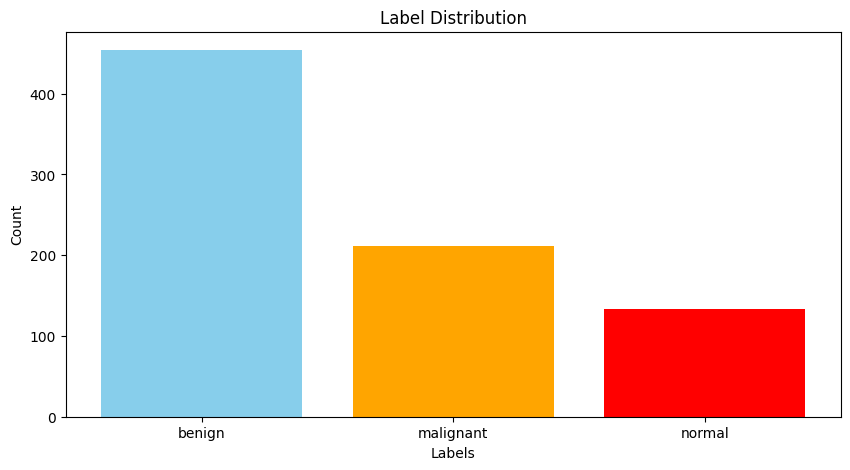

labels
benign       454
malignant    211
normal       133
Name: count, dtype: int64
Image dimensions: 495 x 491 pixels
Number of channels: 3


In [ ]:
import os
import matplotlib.pyplot as plt
import cv2
import pandas as pd

# Dataset path
dataset_path = '/content/breast_data_with_mask/Dataset_BUSI_with_GT'  # Replace with your dataset path

# Get image types and labels
image_types = []
labels = []

for folder_name in ['normal', 'benign', 'malignant']:
    folder_path = os.path.join(dataset_path, folder_name)
    for filename in os.listdir(folder_path):
        if filename.endswith('.png') and not filename.endswith('_mask.png'):
            image_types.append(filename)
            labels.append(folder_name)

# Analyze label distribution
df = pd.DataFrame({'labels': labels})
label_counts = df['labels'].value_counts()

plt.figure(figsize=(10, 5))
plt.bar(label_counts.index, label_counts.values, color=['skyblue', 'orange', 'red'])
plt.title('Label Distribution')
plt.xlabel('Labels')
plt.ylabel('Count')
plt.show()
print(label_counts)

# Example: Get image characteristics (dimensions, channels)
example_image_path = os.path.join(dataset_path, 'normal', image_types[0])
image = cv2.imread(example_image_path)
height, width, channels = image.shape
print(f"Image dimensions: {width} x {height} pixels")
print(f"Number of channels: {channels}")

Load and display a sample ultrasound image and mask from Dataset 1:

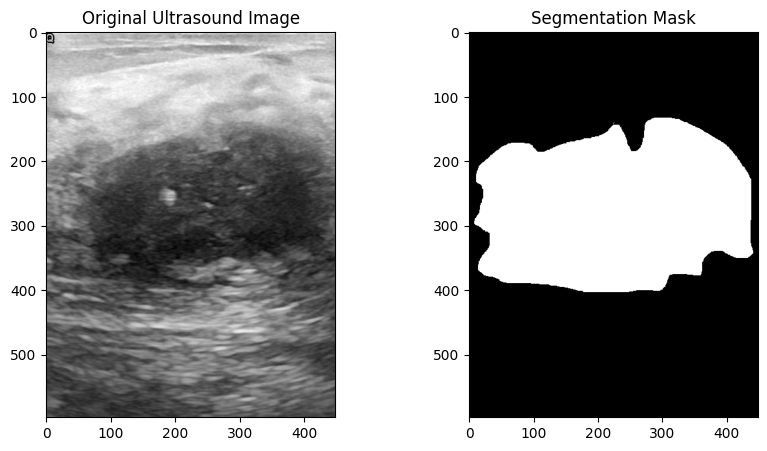

In [ ]:
import matplotlib.pyplot as plt
import cv2
import os

# Load and display a sample ultrasound image and its mask from Dataset 1
image_path = "/content/breast_data_with_mask/Dataset_BUSI_with_GT/malignant/malignant (1).png"
mask_path = "/content/breast_data_with_mask/Dataset_BUSI_with_GT/malignant/malignant (1)_mask.png"

image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(image, cmap='gray')
plt.title("Original Ultrasound Image")

plt.subplot(1, 2, 2)
plt.imshow(mask, cmap='gray')
plt.title("Segmentation Mask")

plt.show()

##Handling class imbalance with Data Augmentation using Albumentation on ***breast_data_with_mask (dataset-1)***

Importing necessary libraries.

In [ ]:
import albumentations as A
import cv2
import os
import shutil
from concurrent.futures import ThreadPoolExecutor

Declaring function: augment_image_and_mask

In [ ]:
def augment_image_and_mask(image_path, mask_path, augmentation):
    image = cv2.imread(image_path)
    mask = cv2.imread(mask_path)

    # Ensure that images and masks are read in correctly
    if image is None:
      raise FileNotFoundError(f"Image not found at: {image_path}")
    if mask is None:
      raise FileNotFoundError(f"Mask not found at: {mask_path}")

    # Ensure both images are read as color images to be used with Albumentations
    if len(image.shape) == 2:
      image = cv2.cvtColor(image, cv2.COLOR_GRAY2RGB)
    if len(mask.shape) == 2:
      mask = cv2.cvtColor(mask, cv2.COLOR_GRAY2RGB)

    # Apply the augmentation
    augmented = augmentation(image=image, mask=mask)
    aug_img = augmented['image']
    aug_mask = augmented['mask']

    return aug_img, aug_mask

Function for generating augmented image only:

In [ ]:
def augment_image(image_path, augmentation):
    image = cv2.imread(image_path)

    # Ensure that images and masks are read in correctly
    if image is None:
      raise FileNotFoundError(f"Image not found at: {image_path}")

    # Ensure both images are read as color images to be used with Albumentations
    if len(image.shape) == 2:
        image = cv2.cvtColor(image, cv2.COLOR_GRAY2RGB)

    # Apply the augmentation
    augmented = augmentation(image=image)
    aug_img = augmented['image']

    return aug_img

Generating augmented data to the dataset-1:

In [ ]:
def augment_data(input_dir, output_dir, target_images):
    """Augments images to balance the dataset. Args:
        input_dir (str): Path to the original dataset.
        output_dir (str): Path to store augmented data.
        target_images (int): The target number of images per class."""

    # Define the augmentation pipeline
    augmentation = A.Compose([
        A.HorizontalFlip(p=0.5),
        A.Rotate(limit=20, p=0.5),
        A.RandomBrightnessContrast(p=0.2),
        A.ShiftScaleRotate(shift_limit=0.1, scale_limit=0.1, rotate_limit=20, p=0.5)
    ])

    # Process each class
    for class_name in ["malignant", "normal", "benign"]:
        input_class_dir = os.path.join(input_dir, class_name)
        output_class_dir = os.path.join(output_dir, class_name)
        os.makedirs(output_class_dir, exist_ok=True)

        filenames = [f for f in os.listdir(input_class_dir) if f.endswith(".png") and "mask" not in f]
        num_original_images = len(filenames)
        num_augmentations_needed = max(0, target_images - num_original_images)  # Same target for all
        augmented_count = 0

        if num_original_images > 0:
            for i, filename in enumerate(filenames):
                image_path = os.path.join(input_class_dir, filename)

                # Handle masks for malignant and benign only
                if class_name in ["malignant", "benign"]:
                    mask_path = image_path.replace(".png", "_mask.png")
                    if not os.path.exists(mask_path):
                        print(f"Warning: Mask not found for image {filename}, skipping augmentation for this file.")
                        continue
                    shutil.copy(mask_path, output_class_dir)  # Copy original mask

                # Copy original image for all classes
                shutil.copy(image_path, output_class_dir)

                # Augmentation loop
                while augmented_count < num_augmentations_needed:
                    if class_name in ["malignant", "benign"]:
                        aug_img, aug_mask = augment_image_and_mask(image_path, mask_path, augmentation)
                        mask_save_path = os.path.join(output_class_dir, f"{filename[:-4]}_mask_aug{augmented_count}.png")
                        cv2.imwrite(mask_save_path, aug_mask)  # Save augmented mask
                    else:  # Normal class - only augment image
                        aug_img = augment_image(image_path, augmentation)

                    img_save_path = os.path.join(output_class_dir, f"{filename[:-4]}_aug{augmented_count}.png")
                    cv2.imwrite(img_save_path, aug_img)  # Save augmented image
                    augmented_count += 1

# Directory paths
input_dir = "/content/breast_data_with_mask/Dataset_BUSI_with_GT"
output_dir = "augmented_dataset_1"
target_images = 454 # set target image to the class with the max images

augment_data(input_dir, output_dir, target_images)

/usr/local/lib/python3.11/dist-packages/albumentations/core/validation.py:87: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)


Checking classes

In [ ]:
import os

dataset_path = '/content/augmented_dataset_1' # Or where augmented dataset is stored

for folder_name in ['normal', 'benign', 'malignant']:
    folder_path = os.path.join(dataset_path, folder_name)
    image_count = 0
    mask_count = 0
    for filename in os.listdir(folder_path):
        if filename.endswith('.png'):
            if "mask" in filename:
                mask_count += 1
            else:
                image_count +=1

    print(f"Class {folder_name}: {image_count} images and {mask_count} masks")

Class normal: 454 images and 0 masks
Class benign: 454 images and 454 masks
Class malignant: 454 images and 454 masks


Analyzing and Visualizing the class distribution of dataset for dataset-1 after augmentation:

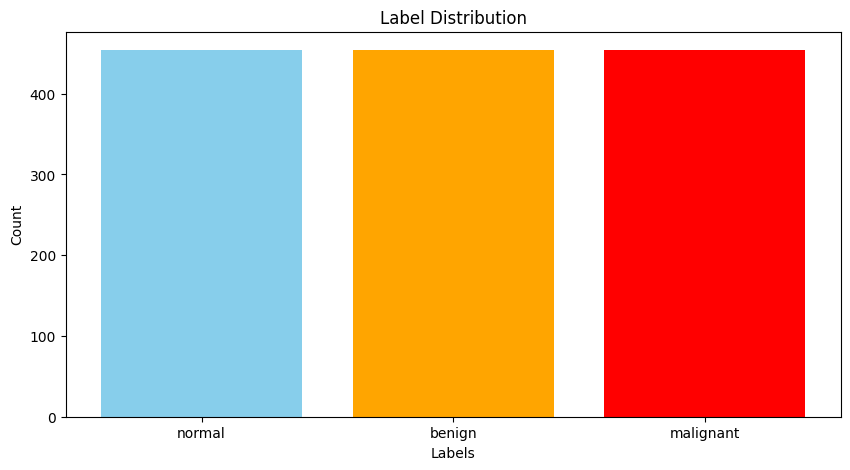

labels
normal       454
benign       454
malignant    454
Name: count, dtype: int64
Image dimensions: 495 x 491 pixels
Number of channels: 3


In [ ]:
import os
import matplotlib.pyplot as plt
import cv2
import pandas as pd
import re

# Dataset path
dataset_path = '/content/augmented_dataset_1'

# Get image types and labels
image_types = []
labels = []

for folder_name in ['normal', 'benign', 'malignant']:
    folder_path = os.path.join(dataset_path, folder_name)
    for filename in os.listdir(folder_path):
        if filename.endswith('.png') and not filename.endswith('_mask.png') and not re.search(r'_mask_aug\d+\.png$', filename):
            image_types.append(filename)
            labels.append(folder_name)

# Analyze label distribution
df = pd.DataFrame({'labels': labels})
label_counts = df['labels'].value_counts()

plt.figure(figsize=(10, 5))
plt.bar(label_counts.index, label_counts.values, color=['skyblue', 'orange', 'red'])
plt.title('Label Distribution')
plt.xlabel('Labels')
plt.ylabel('Count')
plt.show()
print(label_counts)

# Example: Get image characteristics (dimensions, channels)
example_image_path = os.path.join(dataset_path, 'normal', image_types[0])
image = cv2.imread(example_image_path)
height, width, channels = image.shape
print(f"Image dimensions: {width} x {height} pixels")
print(f"Number of channels: {channels}")

## Dataset for classification, dataset-2:

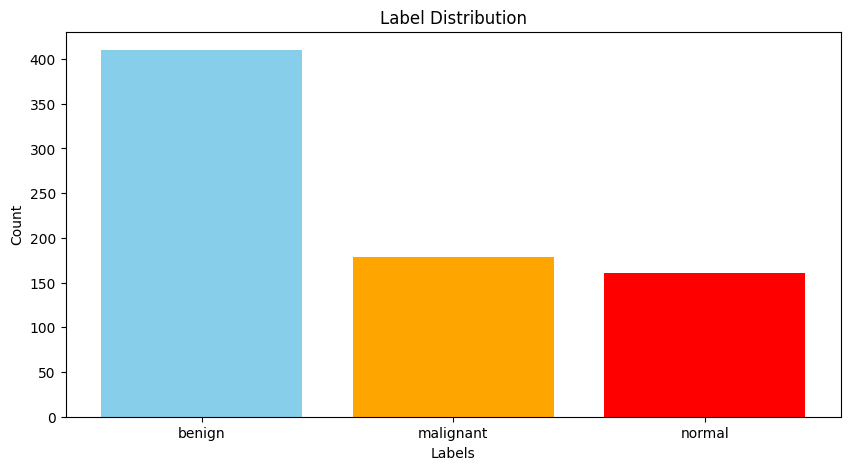

labels
benign       410
malignant    179
normal       161
Name: count, dtype: int64
Image dimensions: 495 x 491 pixels
Number of channels: 3


In [ ]:
import os
import matplotlib.pyplot as plt
import cv2
import pandas as pd

# Dataset path
dataset_path = '/content/breast_dataset_for_classification/BUSI_Corrected'

# Get image types and labels
image_types = []
labels = []

for folder_name in ['normal', 'benign', 'malignant']:
    folder_path = os.path.join(dataset_path, folder_name)
    for filename in os.listdir(folder_path):
        if filename.endswith('.png') and not filename.endswith('_mask.png'):
            image_types.append(filename)
            labels.append(folder_name)

# Analyze label distribution
df = pd.DataFrame({'labels': labels})
label_counts = df['labels'].value_counts()

plt.figure(figsize=(10, 5))
plt.bar(label_counts.index, label_counts.values, color=['skyblue', 'orange', 'red'])
plt.title('Label Distribution')
plt.xlabel('Labels')
plt.ylabel('Count')
plt.show()
print(label_counts)

# Example: Get image characteristics (dimensions, channels)
example_image_path = os.path.join(dataset_path, 'normal', image_types[0])
image = cv2.imread(example_image_path)
height, width, channels = image.shape
print(f"Image dimensions: {width} x {height} pixels")
print(f"Number of channels: {channels}")

Load and display a sample ultrasound image from Dataset 2:



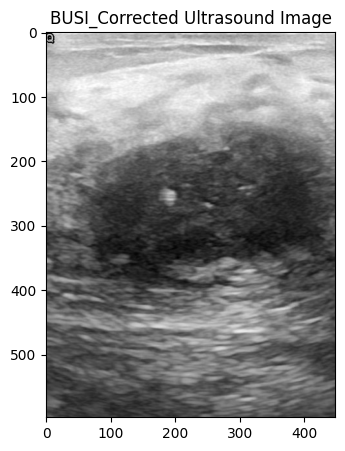

In [ ]:
import matplotlib.pyplot as plt
import cv2
import os

# Load and display a sample ultrasound image and its mask from Dataset 1
image_path = "/content/breast_dataset_for_classification/BUSI_Corrected/malignant/malignant (1).png"

image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)

plt.figure(figsize=(10, 5))
plt.imshow(image, cmap='gray')
plt.title("BUSI_Corrected Ultrasound Image")

plt.show()

##Handling class imbalance with Data Augmentation using Albumentation on ***BUSI_Corrected (dataset-2)***

Importing necessary libraries.

In [ ]:
import albumentations as A
import cv2
import os
import shutil
from concurrent.futures import ThreadPoolExecutor

Function for generating augmented image only:

In [ ]:
def augment_image(image_path, augmentation):
    image = cv2.imread(image_path)

    # Ensure that images and masks are read in correctly
    if image is None:
      raise FileNotFoundError(f"Image not found at: {image_path}")

    # Ensure both images are read as color images to be used with Albumentations
    if len(image.shape) == 2:
        image = cv2.cvtColor(image, cv2.COLOR_GRAY2RGB)

    # Apply the augmentation
    augmented = augmentation(image=image)
    aug_img = augmented['image']

    return aug_img

Generating augmented data to the dataset-1:

In [ ]:
def augment_data(input_dir, output_dir, target_images):
    """Augments images to balance the dataset. Args:
        input_dir (str): Path to the original dataset.
        output_dir (str): Path to store augmented data.
        target_images (int): The target number of images per class."""

    # Define the augmentation pipeline
    augmentation = A.Compose([
        A.HorizontalFlip(p=0.5),
        A.Rotate(limit=20, p=0.5),
        A.RandomBrightnessContrast(p=0.2),
        A.ShiftScaleRotate(shift_limit=0.1, scale_limit=0.1, rotate_limit=20, p=0.5)
    ])

    # Process each class
    for class_name in ["malignant", "normal"]:  # Only process malignant and normal
        input_class_dir = os.path.join(input_dir, class_name)
        output_class_dir = os.path.join(output_dir, class_name)
        os.makedirs(output_class_dir, exist_ok=True)

        filenames = [f for f in os.listdir(input_class_dir) if f.endswith(".png")]
        num_original_images = len(filenames)
        num_augmentations_needed = max(0, target_images - num_original_images)
        augmented_count = 0

        if num_original_images > 0:
            for i, filename in enumerate(filenames):
                image_path = os.path.join(input_class_dir, filename)

                # Copy original image
                shutil.copy(image_path, output_class_dir)

                # Augmentation loop
                while augmented_count < num_augmentations_needed:
                    # Augment image
                    aug_img = augment_image(image_path, augmentation)

                    img_save_path = os.path.join(output_class_dir, f"{filename[:-4]}_aug{augmented_count}.png")
                    cv2.imwrite(img_save_path, aug_img)  # Save augmented image
                    augmented_count += 1

# Copy the 'benign' folder as is
    benign_input_dir = os.path.join(input_dir, "benign")
    benign_output_dir = os.path.join(output_dir, "benign")
    os.makedirs(benign_output_dir, exist_ok=True)
    for filename in os.listdir(benign_input_dir):
        if filename.endswith(".png"):
            shutil.copy(os.path.join(benign_input_dir, filename), benign_output_dir)


# Directory paths
input_dir = "/content/breast_dataset_for_classification/BUSI_Corrected"
output_dir = "augmented_dataset_2"
target_images = 410

augment_data(input_dir, output_dir, target_images)

/usr/local/lib/python3.11/dist-packages/albumentations/core/validation.py:87: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)


Checking classes

In [ ]:
import os

dataset_path = '/content/augmented_dataset_2' # Or where augmented dataset is stored

for folder_name in ['normal', 'benign', 'malignant']:
    folder_path = os.path.join(dataset_path, folder_name)
    image_count = 0
    mask_count = 0
    for filename in os.listdir(folder_path):
        if filename.endswith('.png'):
            if "mask" in filename:
                mask_count += 1
            else:
                image_count +=1

    print(f"Class {folder_name}: {image_count} images and {mask_count} masks")

Class normal: 410 images and 0 masks
Class benign: 410 images and 0 masks
Class malignant: 410 images and 0 masks


Analyzing and Visualizing the class distribution of dataset for dataset-1 after augmentation:

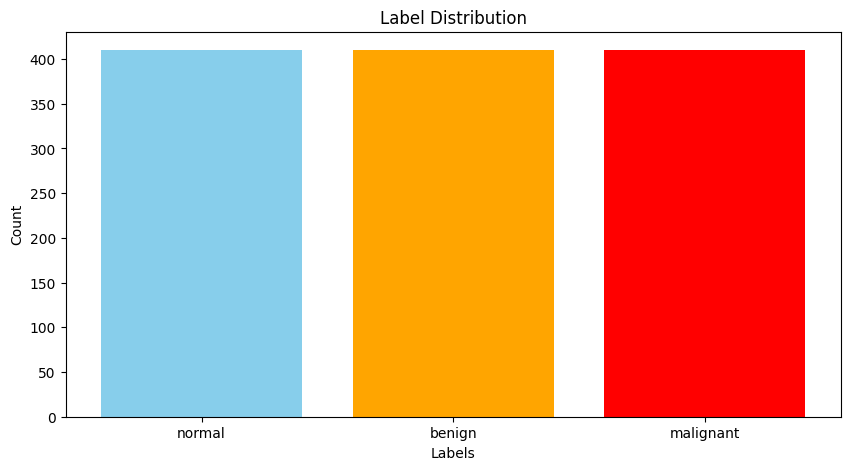

labels
normal       410
benign       410
malignant    410
Name: count, dtype: int64
Image dimensions: 763 x 611 pixels
Number of channels: 3


In [ ]:
import os
import matplotlib.pyplot as plt
import cv2
import pandas as pd
import re

# Dataset path
dataset_path = '/content/augmented_dataset_2'

# Get image types and labels
image_types = []
labels = []

for folder_name in ['normal', 'benign', 'malignant']:
    folder_path = os.path.join(dataset_path, folder_name)
    for filename in os.listdir(folder_path):
        if filename.endswith('.png'):
            image_types.append(filename)
            labels.append(folder_name)

# Analyze label distribution
df = pd.DataFrame({'labels': labels})
label_counts = df['labels'].value_counts()

plt.figure(figsize=(10, 5))
plt.bar(label_counts.index, label_counts.values, color=['skyblue', 'orange', 'red'])
plt.title('Label Distribution')
plt.xlabel('Labels')
plt.ylabel('Count')
plt.show()
print(label_counts)

# Example: Get image characteristics (dimensions, channels)
example_image_path = os.path.join(dataset_path, 'normal', image_types[0])
image = cv2.imread(example_image_path)
height, width, channels = image.shape
print(f"Image dimensions: {width} x {height} pixels")
print(f"Number of channels: {channels}")

In [ ]:
# Zip the augmented dataset folder in one line
import shutil
shutil.make_archive('/content/drive/MyDrive/dataset/augmented_dataset_2', 'zip', output_dir)
print("Augmented dataset zipped and saved to Google Drive successfully!")

Augmented dataset zipped and saved to Google Drive successfully!


# **Part 01: Developing a Segmentation Model**

##Training the segmentation model using DATASET_1:

U-net Segmentation model have been used here to train the dataset-1.

In [ ]:
## Making essential imports
import os
import numpy as np
import pandas as pd
import re
import matplotlib.pyplot as plt
import cv2
import tensorflow as tf

Loads and Preprocesses Data

In [ ]:
framObjTrain = {'img': [], 'mask': []}

def LoadData(frameObj=None, imgPath=None, maskPath=None, shape=224):
    frameObj['img'] = []
    frameObj['mask'] = []

    imgNames = os.listdir(imgPath)

    imgAddr = imgPath + '/'
    maskAddr = maskPath + '/'

    for imgName in imgNames:
        if imgName.endswith('.png') and not imgName.endswith('_mask.png') and not imgName.endswith('_mask_1.png'):
            img = plt.imread(imgAddr + imgName)
            maskName1 = imgName.split('.png')[0] + '_mask.png'
            maskName2 = imgName.split('.png')[0] + '_mask_1.png'

            if os.path.exists(maskAddr + maskName1):
                mask1 = plt.imread(maskAddr + maskName1)

                # Resize and ensure 3 channels for images:
                img = cv2.resize(img, (shape, shape))
                if len(img.shape) == 2:  # If grayscale, convert to 3 channels
                    img = cv2.cvtColor(img, cv2.COLOR_GRAY2RGB)

                # Resize and ensure 1 channel for masks:
                mask1 = cv2.resize(mask1, (shape, shape))
                if len(mask1.shape) == 3: # If RGB, convert to grayscale
                    mask1 = cv2.cvtColor(mask1, cv2.COLOR_RGB2GRAY)
                mask1 = mask1[..., np.newaxis]  # Add channel dimension if missing

                frameObj['img'].append(img)
                frameObj['mask'].append(mask1)
            if os.path.exists(maskAddr + maskName2):
                mask2 = plt.imread(maskAddr + maskName2)

                # Resize and ensure 3 channels for images:
                img = cv2.resize(img, (shape, shape))
                if len(img.shape) == 2:  # If grayscale, convert to 3 channels
                    img = cv2.cvtColor(img, cv2.COLOR_GRAY2RGB)

                # Resize and ensure 1 channel for masks:
                mask2 = cv2.resize(mask2, (shape, shape))
                if len(mask2.shape) == 3: # If RGB, convert to grayscale
                    mask2 = cv2.cvtColor(mask2, cv2.COLOR_RGB2GRAY)
                mask2 = mask2[..., np.newaxis]  # Add channel dimension if missing

                frameObj['img'].append(img)
                frameObj['mask'].append(mask2)

    print("Total images loaded:", len(frameObj['img']))
    return frameObj

###Loading Benign Samples and Predicting Mask and save the model for  benign_predicted_mask

In [ ]:
# Load benign samples
benignObjTrain = LoadData(framObjTrain, imgPath='/content/augmented_dataset_1/benign',
                        maskPath='/content/augmented_dataset_1/benign', shape=224)

Total images loaded: 437


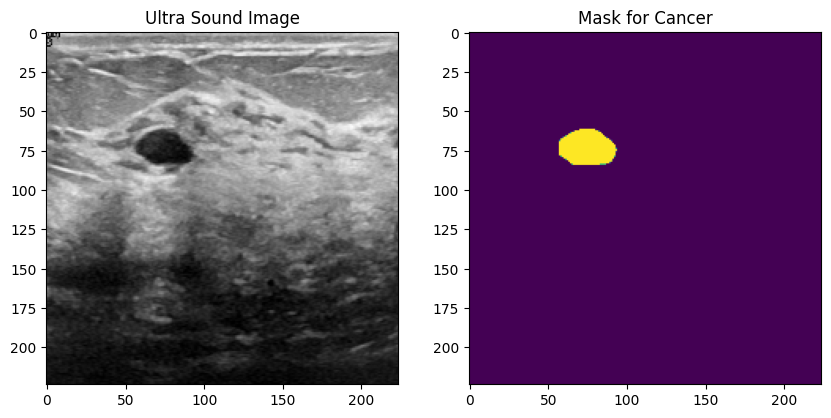

In [ ]:
## displaying data loaded by our function
plt.figure(figsize = (10, 7))
plt.subplot(1,2,1)
plt.imshow(benignObjTrain['img'][1])
plt.title('Ultra Sound Image')
plt.subplot(1,2,2)
plt.imshow(benignObjTrain['mask'][1])
plt.title('Mask for Cancer')
plt.show()

In [ ]:
!pip install superml

Spliting the data into training and testing sets using train_test_split.

In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(benignObjTrain['img'], benignObjTrain['mask'], test_size = 0.30, random_state = 42)

Building the U-Net Model by defining functions, **Conv2dBlock** and **GiveMeUnet**:

In [ ]:
def Conv2dBlock(inputTensor, numFilters, kernelSize = 3, doBatchNorm = True):
    x = tf.keras.layers.Conv2D(filters = numFilters, kernel_size = (kernelSize, kernelSize),
                              kernel_initializer = 'he_normal', padding = 'same') (inputTensor)

    if doBatchNorm:
        x = tf.keras.layers.BatchNormalization()(x)

    x =tf.keras.layers.Activation('relu')(x)

    x = tf.keras.layers.Conv2D(filters = numFilters, kernel_size = (kernelSize, kernelSize),
                              kernel_initializer = 'he_normal', padding = 'same') (x)
    if doBatchNorm:
        x = tf.keras.layers.BatchNormalization()(x)

    x = tf.keras.layers.Activation('relu')(x)

    return x

def GiveMeUnet(inputImage, numFilters = 16, droupouts = 0.1, doBatchNorm = True):
    c1 = Conv2dBlock(inputImage, numFilters * 1, kernelSize = 3, doBatchNorm = doBatchNorm)
    p1 = tf.keras.layers.MaxPooling2D((2,2))(c1)
    p1 = tf.keras.layers.Dropout(droupouts)(p1)

    c2 = Conv2dBlock(p1, numFilters * 2, kernelSize = 3, doBatchNorm = doBatchNorm)
    p2 = tf.keras.layers.MaxPooling2D((2,2))(c2)
    p2 = tf.keras.layers.Dropout(droupouts)(p2)

    c3 = Conv2dBlock(p2, numFilters * 4, kernelSize = 3, doBatchNorm = doBatchNorm)
    p3 = tf.keras.layers.MaxPooling2D((2,2))(c3)
    p3 = tf.keras.layers.Dropout(droupouts)(p3)

    c4 = Conv2dBlock(p3, numFilters * 8, kernelSize = 3, doBatchNorm = doBatchNorm)
    p4 = tf.keras.layers.MaxPooling2D((2,2))(c4)
    p4 = tf.keras.layers.Dropout(droupouts)(p4)

    c5 = Conv2dBlock(p4, numFilters * 16, kernelSize = 3, doBatchNorm = doBatchNorm)

    u6 = tf.keras.layers.Conv2DTranspose(numFilters*8, (3, 3), strides = (2, 2), padding = 'same')(c5)
    u6 = tf.keras.layers.concatenate([u6, c4])
    u6 = tf.keras.layers.Dropout(droupouts)(u6)
    c6 = Conv2dBlock(u6, numFilters * 8, kernelSize = 3, doBatchNorm = doBatchNorm)

    u7 = tf.keras.layers.Conv2DTranspose(numFilters*4, (3, 3), strides = (2, 2), padding = 'same')(c6)
    u7 = tf.keras.layers.concatenate([u7, c3])
    u7 = tf.keras.layers.Dropout(droupouts)(u7)
    c7 = Conv2dBlock(u7, numFilters * 4, kernelSize = 3, doBatchNorm = doBatchNorm)

    u8 = tf.keras.layers.Conv2DTranspose(numFilters*2, (3, 3), strides = (2, 2), padding = 'same')(c7)
    u8 = tf.keras.layers.concatenate([u8, c2])
    u8 = tf.keras.layers.Dropout(droupouts)(u8)
    c8 = Conv2dBlock(u8, numFilters * 2, kernelSize = 3, doBatchNorm = doBatchNorm)

    u9 = tf.keras.layers.Conv2DTranspose(numFilters*1, (3, 3), strides = (2, 2), padding = 'same')(c8)
    u9 = tf.keras.layers.concatenate([u9, c1])
    u9 = tf.keras.layers.Dropout(droupouts)(u9)
    c9 = Conv2dBlock(u9, numFilters * 1, kernelSize = 3, doBatchNorm = doBatchNorm)

    output = tf.keras.layers.Conv2D(1, (1, 1), activation = 'sigmoid')(c9)
    model = tf.keras.Model(inputs = [inputImage], outputs = [output])
    return model

#### Model Instantiation

In [ ]:
batch_size = 128
inputs = tf.keras.layers.Input((224, 224, 3), name='keras_tensor_228')
rkoshaheds_model = GiveMeUnet(inputs, droupouts= 0.3)
rkoshaheds_model.compile(optimizer = 'Adam', loss = 'binary_crossentropy', metrics = ['accuracy'] )
rkoshaheds_model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ keras_tensor_228          │ (None, 224, 224, 3)    │              0 │ -                      │
│ (InputLayer)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d (Conv2D)           │ (None, 224, 224, 16)   │            448 │ keras_tensor_228[0][0] │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ batch_normalization       │ (None, 224, 224, 16)   │             64 │ conv2d[0][0]           │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ activation (Activation)   │ (None, 224, 224, 16)   │              0 │ batch_normalization[0… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_1 (Conv2D)         │ (None, 224, 224, 16)   │          2,320 │ activation[0][0]       │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ batch_normalization_1     │ (None, 224, 224, 16)   │             64 │ conv2d_1[0][0]         │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ activation_1 (Activation) │ (None, 224, 224, 16)   │              0 │ batch_normalization_1… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ max_pooling2d             │ (None, 112, 112, 16)   │              0 │ activation_1[0][0]     │
│ (MaxPooling2D)            │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dropout (Dropout)         │ (None, 112, 112, 16)   │              0 │ max_pooling2d[0][0]    │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_2 (Conv2D)         │ (None, 112, 112, 32)   │          4,640 │ dropout[0][0]          │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ batch_normalization_2     │ (None, 112, 112, 32)   │            128 │ conv2d_2[0][0]         │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ activation_2 (Activation) │ (None, 112, 112, 32)   │              0 │ batch_normalization_2… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_3 (Conv2D)         │ (None, 112, 112, 32)   │          9,248 │ activation_2[0][0]     │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ batch_normalization_3     │ (None, 112, 112, 32)   │            128 │ conv2d_3[0][0]         │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ activation_3 (Activation) │ (None, 112, 112, 32)   │              0 │ batch_normalization_3… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ max_pooling2d_1           │ (None, 56, 56, 32)     │              0 │ activation_3[0][0]     │
│ (MaxPooling2D)            │                        │                │                        │
├──────────────────────

 Total params: 2,164,593 (8.26 MB)

 Trainable params: 2,161,649 (8.25 MB)

 Non-trainable params: 2,944 (11.50 KB)

In [ ]:
hisVal = rkoshaheds_model.fit({'keras_tensor_228': np.array(X_train)}, np.array(y_train), batch_size=batch_size, epochs=180)

Epoch 1/180
3/3 ━━━━━━━━━━━━━━━━━━━━ 121s 17s/step - accuracy: 0.4030 - loss: 0.8563
Epoch 2/180
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 646ms/step - accuracy: 0.3924 - loss: 0.7897
Epoch 3/180
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 651ms/step - accuracy: 0.4660 - loss: 0.7353
Epoch 4/180
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 655ms/step - accuracy: 0.6115 - loss: 0.6788
Epoch 5/180
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 659ms/step - accuracy: 0.7638 - loss: 0.6214
Epoch 6/180
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 661ms/step - accuracy: 0.8589 - loss: 0.5666
Epoch 7/180
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 665ms/step - accuracy: 0.9049 - loss: 0.5083
Epoch 8/180
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 666ms/step - accuracy: 0.9164 - loss: 0.4773
Epoch 9/180
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 670ms/step - accuracy: 0.9259 - loss: 0.4540
Epoch 10/180
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 672ms/step - accuracy: 0.9295 - loss: 0.4272
Epoch 11/180
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 680ms/step - accuracy: 0.9279 - loss: 0.4151
Epoch 12/180
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 685ms/step - accuracy:

In [ ]:
retVal = rkoshaheds_model.fit({'keras_tensor_228': np.array(X_test)}, np.array(y_test), epochs = 180)

Epoch 1/180
5/5 ━━━━━━━━━━━━━━━━━━━━ 49s 5s/step - accuracy: 0.9621 - loss: 0.1364
Epoch 2/180
5/5 ━━━━━━━━━━━━━━━━━━━━ 34s 194ms/step - accuracy: 0.9596 - loss: 0.1391
Epoch 3/180
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 198ms/step - accuracy: 0.9625 - loss: 0.1278
Epoch 4/180
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 196ms/step - accuracy: 0.9525 - loss: 0.1514
Epoch 5/180
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 195ms/step - accuracy: 0.9549 - loss: 0.1470
Epoch 6/180
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 195ms/step - accuracy: 0.9529 - loss: 0.1432
Epoch 7/180
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 196ms/step - accuracy: 0.9587 - loss: 0.1273
Epoch 8/180
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 193ms/step - accuracy: 0.9560 - loss: 0.1324
Epoch 9/180
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 198ms/step - accuracy: 0.9626 - loss: 0.1161
Epoch 10/180
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 198ms/step - accuracy: 0.9646 - loss: 0.1099
Epoch 11/180
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 199ms/step - accuracy: 0.9698 - loss: 0.0960
Epoch 12/180
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 200ms/step - accuracy: 

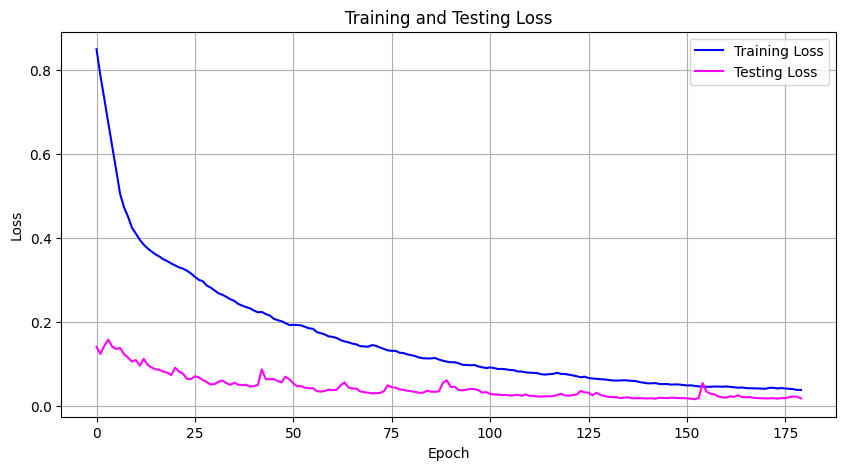

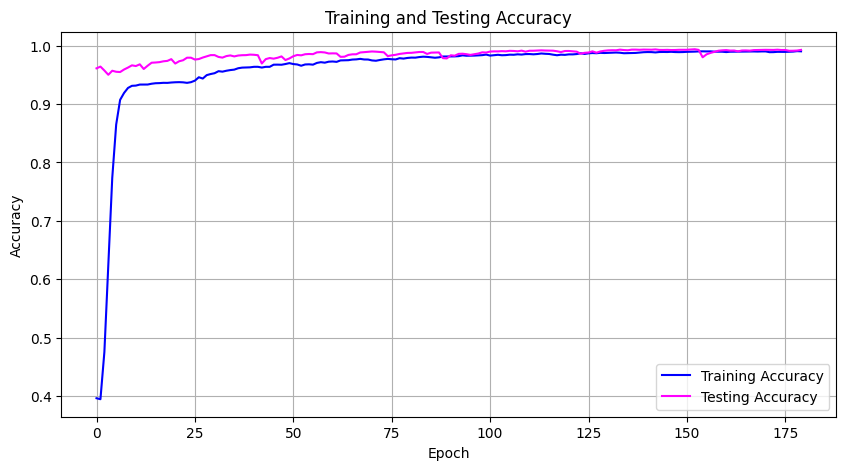

In [ ]:
plt.style.use('default')
plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams['axes.facecolor'] = 'white'

# Accessing training loss ang accuracy:
training_loss = hisVal.history['loss']
training_accuracy = hisVal.history['accuracy']

# Accessing testing loss and accuracy:
testing_loss = retVal.history['loss']
testing_accuracy = retVal.history['accuracy']

# Plotting training and testing metrics:
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 5))

plt.plot(training_loss, label='Training Loss', color='blue')
plt.plot(testing_loss, label='Testing Loss', color='magenta')
plt.title('Training and Testing Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.figure(figsize=(10, 5))
plt.plot(training_accuracy, label='Training Accuracy', color='blue')
plt.plot(testing_accuracy, label='Testing Accuracy', color='magenta')
plt.title('Training and Testing Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

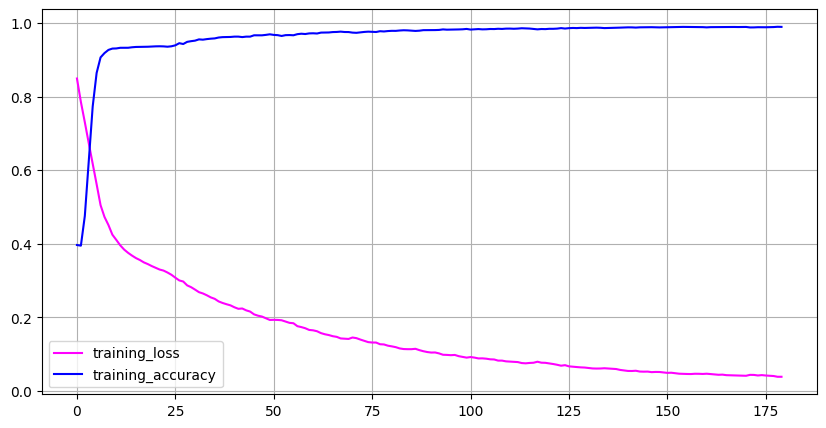

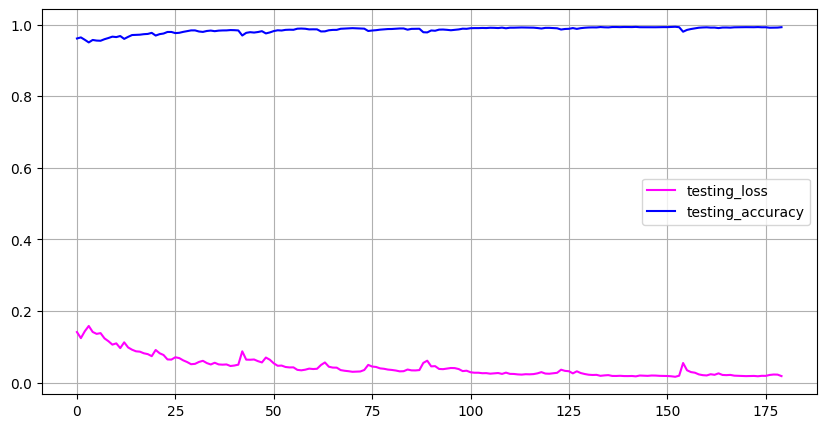

In [ ]:
plt.style.use('default')
plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams['axes.facecolor'] = 'white'

plt.figure(figsize=(10, 5))
plt.plot(hisVal.history['loss'], label = 'training_loss', color='magenta')
plt.plot(hisVal.history['accuracy'], label = 'training_accuracy', color='blue')
plt.legend()
plt.grid(True)

plt.figure(figsize=(10, 5))
plt.plot(retVal.history['loss'], label = 'testing_loss', color='magenta')
plt.plot(retVal.history['accuracy'], label = 'testing_accuracy', color='blue')
plt.legend()
plt.grid(True)

In [ ]:
#Testing
def predict16 (valMap, model, shape = 224):
    ## getting and proccessing val data
    img = valMap['img'][0:16]
    mask = valMap['mask'][0:16]
    #mask = mask[0:16]

    imgProc = img [0:16]
    imgProc = np.array(img)

    predictions = model.predict(imgProc)
    return predictions, imgProc, mask

def Plotter(img, predMask, groundTruth):
    plt.figure(figsize=(9,9))

    plt.subplot(1,3,1)
    plt.imshow(img)
    plt.title(' image')

    plt.subplot(1,3,2)
    plt.imshow(predMask)
    plt.title('Predicted mask')

    plt.subplot(1,3,3)
    plt.imshow(groundTruth)
    plt.title('Actual mask')

/usr/local/lib/python3.11/dist-packages/keras/src/models/functional.py:237: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['keras_tensor_228']
Received: inputs=Tensor(shape=(16, 224, 224, 3))
  warnings.warn(msg)


1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step


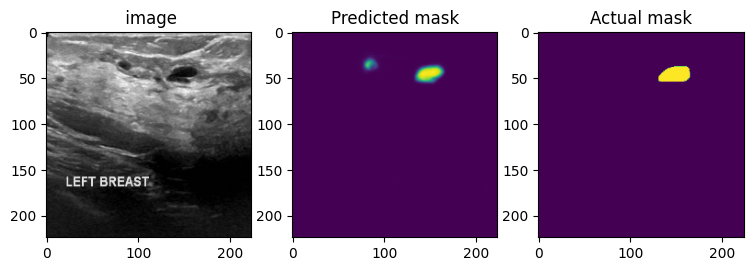

In [ ]:
sixteenPrediction, actuals, masks = predict16(benignObjTrain, rkoshaheds_model)
Plotter(actuals[11], sixteenPrediction[11][:,:,0], masks[11])


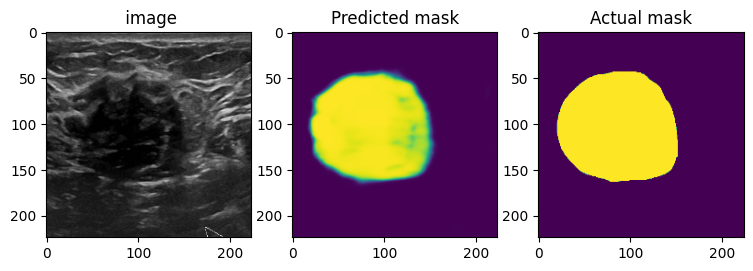

In [ ]:
Plotter(actuals[7], sixteenPrediction[7][:,:,0], masks[7])

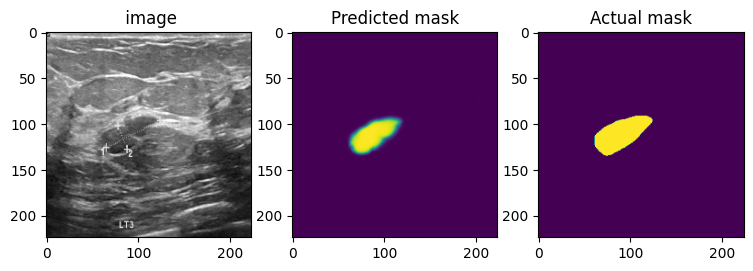

In [ ]:
Plotter(actuals[9], sixteenPrediction[9][:,:,0], masks[9])

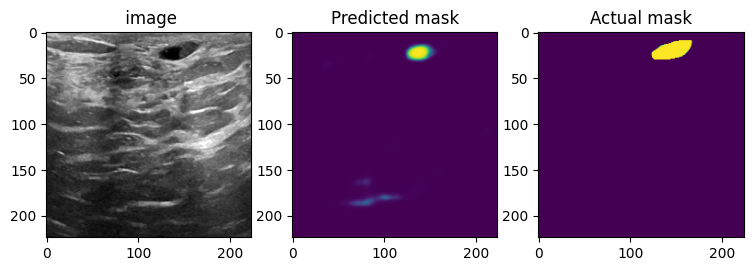

In [ ]:
Plotter(actuals[10], sixteenPrediction[10][:,:,0], masks[10])

In [ ]:
#Saving Model
rkoshaheds_model.save('/content/drive/MyDrive/dataset/benign_predicted_mask.h5')

###Loading Malignent Samples and Predicting Mask and save the model for malignant_predicted_mask

In [ ]:
# Load malignant samples
malignantObjTrain = LoadData(framObjTrain, imgPath='/content/augmented_dataset_1/malignant',
                        maskPath='/content/augmented_dataset_1/malignant', shape=224)

Total images loaded: 210


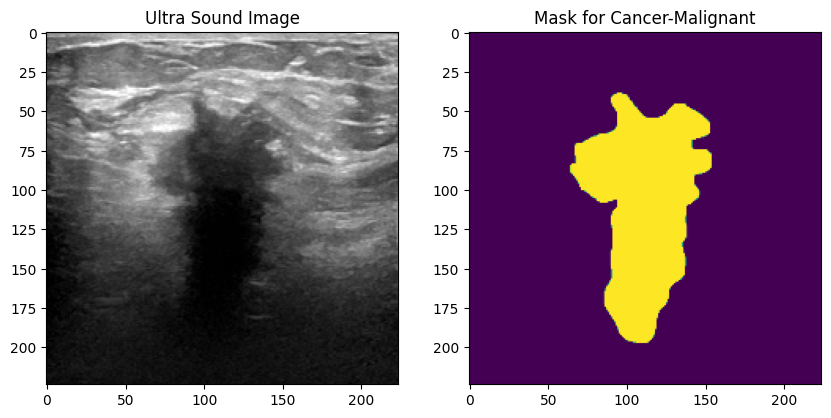

In [ ]:
## displaying data loaded by our function
plt.figure(figsize = (10, 7))
plt.subplot(1,2,1)
plt.imshow(malignantObjTrain['img'][1])
plt.title('Ultra Sound Image')
plt.subplot(1,2,2)
plt.imshow(malignantObjTrain['mask'][1])
plt.title('Mask for Cancer-Malignant')
plt.show()

In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(malignantObjTrain['img'], malignantObjTrain['mask'], test_size = 0.30, random_state = 42)

In [ ]:
def Conv2dBlock(inputTensor, numFilters, kernelSize = 3, doBatchNorm = True):
    x = tf.keras.layers.Conv2D(filters = numFilters, kernel_size = (kernelSize, kernelSize),
                              kernel_initializer = 'he_normal', padding = 'same') (inputTensor)

    if doBatchNorm:
        x = tf.keras.layers.BatchNormalization()(x)

    x =tf.keras.layers.Activation('relu')(x)

    x = tf.keras.layers.Conv2D(filters = numFilters, kernel_size = (kernelSize, kernelSize),
                              kernel_initializer = 'he_normal', padding = 'same') (x)
    if doBatchNorm:
        x = tf.keras.layers.BatchNormalization()(x)

    x = tf.keras.layers.Activation('relu')(x)

    return x

def GiveMeUnet(inputImage, numFilters = 16, droupouts = 0.1, doBatchNorm = True):
    c1 = Conv2dBlock(inputImage, numFilters * 1, kernelSize = 3, doBatchNorm = doBatchNorm)
    p1 = tf.keras.layers.MaxPooling2D((2,2))(c1)
    p1 = tf.keras.layers.Dropout(droupouts)(p1)

    c2 = Conv2dBlock(p1, numFilters * 2, kernelSize = 3, doBatchNorm = doBatchNorm)
    p2 = tf.keras.layers.MaxPooling2D((2,2))(c2)
    p2 = tf.keras.layers.Dropout(droupouts)(p2)

    c3 = Conv2dBlock(p2, numFilters * 4, kernelSize = 3, doBatchNorm = doBatchNorm)
    p3 = tf.keras.layers.MaxPooling2D((2,2))(c3)
    p3 = tf.keras.layers.Dropout(droupouts)(p3)

    c4 = Conv2dBlock(p3, numFilters * 8, kernelSize = 3, doBatchNorm = doBatchNorm)
    p4 = tf.keras.layers.MaxPooling2D((2,2))(c4)
    p4 = tf.keras.layers.Dropout(droupouts)(p4)

    c5 = Conv2dBlock(p4, numFilters * 16, kernelSize = 3, doBatchNorm = doBatchNorm)

    u6 = tf.keras.layers.Conv2DTranspose(numFilters*8, (3, 3), strides = (2, 2), padding = 'same')(c5)
    u6 = tf.keras.layers.concatenate([u6, c4])
    u6 = tf.keras.layers.Dropout(droupouts)(u6)
    c6 = Conv2dBlock(u6, numFilters * 8, kernelSize = 3, doBatchNorm = doBatchNorm)

    u7 = tf.keras.layers.Conv2DTranspose(numFilters*4, (3, 3), strides = (2, 2), padding = 'same')(c6)
    u7 = tf.keras.layers.concatenate([u7, c3])
    u7 = tf.keras.layers.Dropout(droupouts)(u7)
    c7 = Conv2dBlock(u7, numFilters * 4, kernelSize = 3, doBatchNorm = doBatchNorm)

    u8 = tf.keras.layers.Conv2DTranspose(numFilters*2, (3, 3), strides = (2, 2), padding = 'same')(c7)
    u8 = tf.keras.layers.concatenate([u8, c2])
    u8 = tf.keras.layers.Dropout(droupouts)(u8)
    c8 = Conv2dBlock(u8, numFilters * 2, kernelSize = 3, doBatchNorm = doBatchNorm)

    u9 = tf.keras.layers.Conv2DTranspose(numFilters*1, (3, 3), strides = (2, 2), padding = 'same')(c8)
    u9 = tf.keras.layers.concatenate([u9, c1])
    u9 = tf.keras.layers.Dropout(droupouts)(u9)
    c9 = Conv2dBlock(u9, numFilters * 1, kernelSize = 3, doBatchNorm = doBatchNorm)

    output = tf.keras.layers.Conv2D(1, (1, 1), activation = 'sigmoid')(c9)
    output = tf.keras.layers.Reshape((224, 224, 1), dtype=tf.float32)(output)

    model = tf.keras.Model(inputs = [inputImage], outputs = [output])
    return model

#### Model Instantiation

In [ ]:
batch_size = 128
inputs = tf.keras.layers.Input((224, 224, 3), name='keras_tensor_228')
rkoshaheds_model = GiveMeUnet(inputs, droupouts= 0.3)
rkoshaheds_model.compile(optimizer = 'Adam', loss = 'binary_crossentropy', metrics = ['accuracy'] )
rkoshaheds_model.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ keras_tensor_228          │ (None, 224, 224, 3)    │              0 │ -                      │
│ (InputLayer)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_38 (Conv2D)        │ (None, 224, 224, 16)   │            448 │ keras_tensor_228[0][0] │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ batch_normalization_36    │ (None, 224, 224, 16)   │             64 │ conv2d_38[0][0]        │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ activation_36             │ (None, 224, 224, 16)   │              0 │ batch_normalization_3… │
│ (Activation)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_39 (Conv2D)        │ (None, 224, 224, 16)   │          2,320 │ activation_36[0][0]    │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ batch_normalization_37    │ (None, 224, 224, 16)   │             64 │ conv2d_39[0][0]        │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ activation_37             │ (None, 224, 224, 16)   │              0 │ batch_normalization_3… │
│ (Activation)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ max_pooling2d_8           │ (None, 112, 112, 16)   │              0 │ activation_37[0][0]    │
│ (MaxPooling2D)            │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dropout_16 (Dropout)      │ (None, 112, 112, 16)   │              0 │ max_pooling2d_8[0][0]  │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_40 (Conv2D)        │ (None, 112, 112, 32)   │          4,640 │ dropout_16[0][0]       │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ batch_normalization_38    │ (None, 112, 112, 32)   │            128 │ conv2d_40[0][0]        │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ activation_38             │ (None, 112, 112, 32)   │              0 │ batch_normalization_3… │
│ (Activation)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_41 (Conv2D)        │ (None, 112, 112, 32)   │          9,248 │ activation_38[0][0]    │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ batch_normalization_39    │ (None, 112, 112, 32)   │            128 │ conv2d_41[0][0]        │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ activation_39             │ (None, 112, 112, 32)   │              0 │ batch_normalization_3… │
│ (Activation)         

 Total params: 2,164,593 (8.26 MB)

 Trainable params: 2,161,649 (8.25 MB)

 Non-trainable params: 2,944 (11.50 KB)

In [ ]:
hisVal = rkoshaheds_model.fit({'keras_tensor_228': np.array(X_train)}, np.array(y_train), batch_size=batch_size, epochs=180)

Epoch 1/180
2/2 ━━━━━━━━━━━━━━━━━━━━ 51s 23s/step - accuracy: 0.5871 - loss: 0.6736
Epoch 2/180
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 161ms/step - accuracy: 0.6360 - loss: 0.6365
Epoch 3/180
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 166ms/step - accuracy: 0.6786 - loss: 0.6066
Epoch 4/180
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 166ms/step - accuracy: 0.7367 - loss: 0.5695
Epoch 5/180
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 169ms/step - accuracy: 0.7911 - loss: 0.5351
Epoch 6/180
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 166ms/step - accuracy: 0.8354 - loss: 0.5057
Epoch 7/180
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 168ms/step - accuracy: 0.8649 - loss: 0.4760
Epoch 8/180
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 169ms/step - accuracy: 0.8860 - loss: 0.4437
Epoch 9/180
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 177ms/step - accuracy: 0.8874 - loss: 0.4281
Epoch 10/180
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 174ms/step - accuracy: 0.8932 - loss: 0.4084
Epoch 11/180
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 167ms/step - accuracy: 0.8998 - loss: 0.3907
Epoch 12/180
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 164ms/step - accuracy: 

In [ ]:
retVal = rkoshaheds_model.fit({'keras_tensor_228': np.array(X_test)}, np.array(y_test), epochs = 180)

Epoch 1/180
2/2 ━━━━━━━━━━━━━━━━━━━━ 43s 28s/step - accuracy: 0.8923 - loss: 0.3157
Epoch 2/180
2/2 ━━━━━━━━━━━━━━━━━━━━ 39s 231ms/step - accuracy: 0.9007 - loss: 0.2783
Epoch 3/180
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 233ms/step - accuracy: 0.9130 - loss: 0.2278
Epoch 4/180
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 229ms/step - accuracy: 0.9161 - loss: 0.2088
Epoch 5/180
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 229ms/step - accuracy: 0.9238 - loss: 0.1842
Epoch 6/180
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 230ms/step - accuracy: 0.9229 - loss: 0.1827
Epoch 7/180
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 232ms/step - accuracy: 0.9292 - loss: 0.1693
Epoch 8/180
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 232ms/step - accuracy: 0.9332 - loss: 0.1618
Epoch 9/180
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 232ms/step - accuracy: 0.9329 - loss: 0.1579
Epoch 10/180
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 233ms/step - accuracy: 0.9385 - loss: 0.1518
Epoch 11/180
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 233ms/step - accuracy: 0.9436 - loss: 0.1447
Epoch 12/180
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 245ms/step - accuracy:

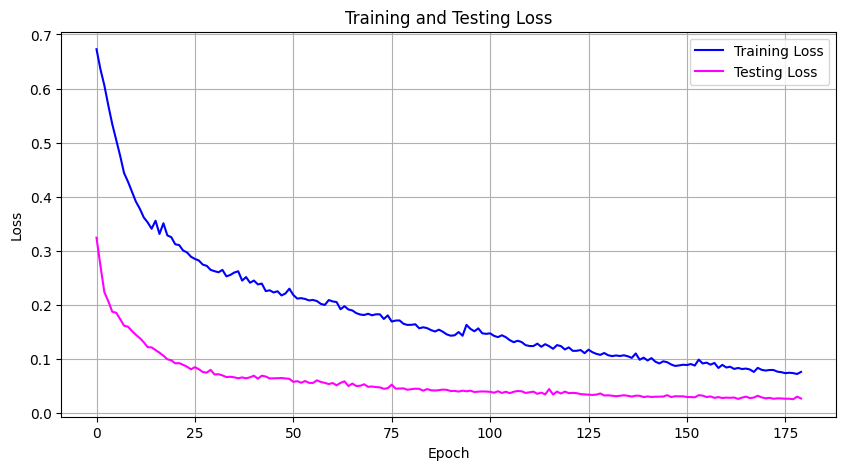

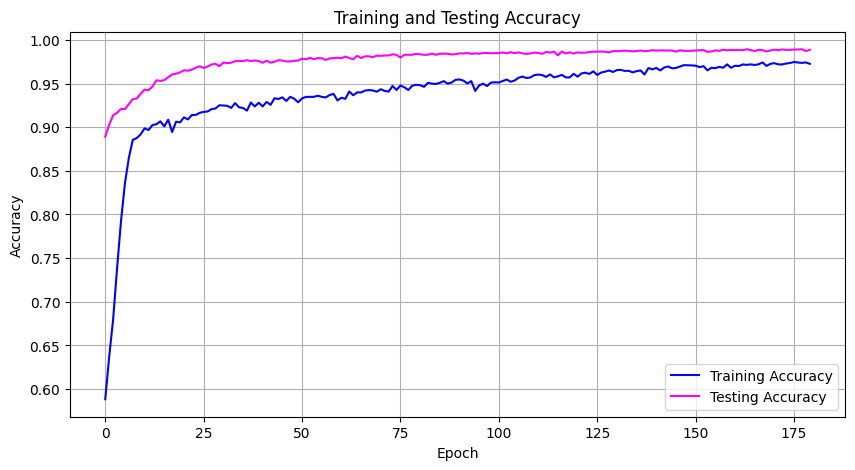

In [ ]:
plt.style.use('default')
plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams['axes.facecolor'] = 'white'

# Accessing training loss ang accuracy:
training_loss = hisVal.history['loss']
training_accuracy = hisVal.history['accuracy']

# Accessing testing loss and accuracy:
testing_loss = retVal.history['loss']
testing_accuracy = retVal.history['accuracy']

# Plotting training and testing metrics:
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 5))

plt.plot(training_loss, label='Training Loss', color='blue')
plt.plot(testing_loss, label='Testing Loss', color='magenta')
plt.title('Training and Testing Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.figure(figsize=(10, 5))
plt.plot(training_accuracy, label='Training Accuracy', color='blue')
plt.plot(testing_accuracy, label='Testing Accuracy', color='magenta')
plt.title('Training and Testing Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

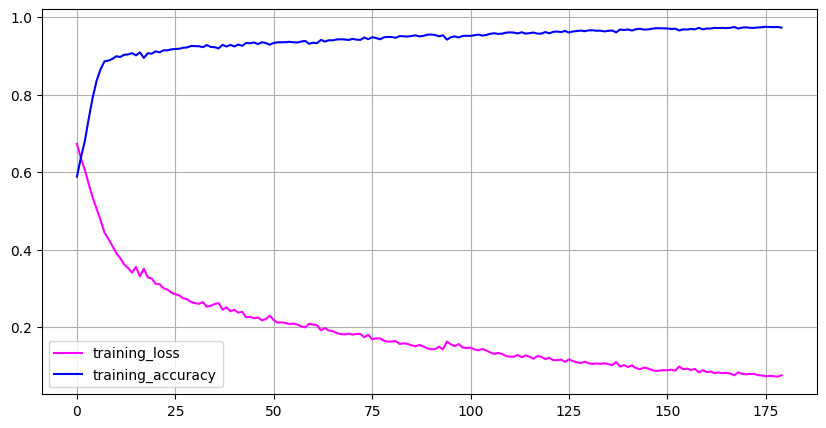

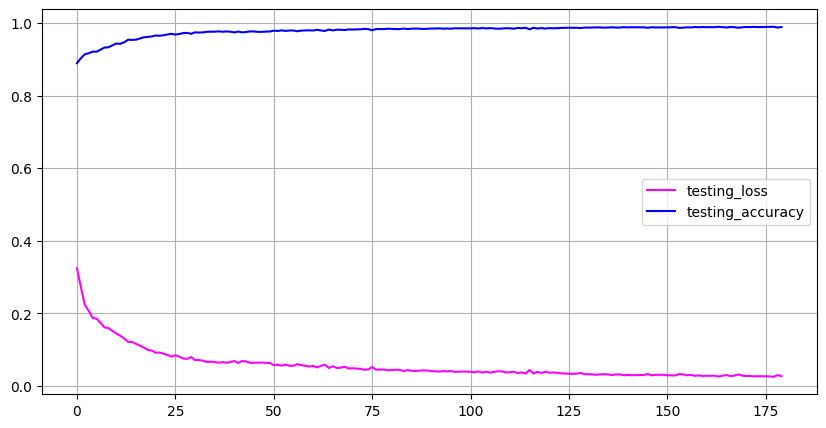

In [ ]:
plt.style.use('default')
plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams['axes.facecolor'] = 'white'

plt.figure(figsize=(10, 5))
plt.plot(hisVal.history['loss'], label = 'training_loss', color='magenta')
plt.plot(hisVal.history['accuracy'], label = 'training_accuracy', color='blue')
plt.legend()
plt.grid(True)

plt.figure(figsize=(10, 5))
plt.plot(retVal.history['loss'], label = 'testing_loss', color='magenta')
plt.plot(retVal.history['accuracy'], label = 'testing_accuracy', color='blue')
plt.legend()
plt.grid(True)

/usr/local/lib/python3.11/dist-packages/keras/src/models/functional.py:237: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['keras_tensor_228']
Received: inputs=Tensor(shape=(16, 224, 224, 3))
  warnings.warn(msg)


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step


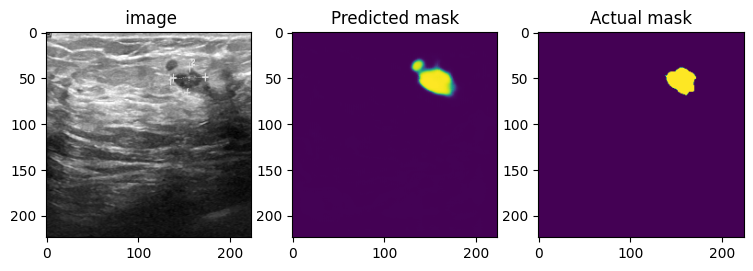

In [ ]:
sixteenPrediction, actuals, masks = predict16(malignantObjTrain, rkoshaheds_model)
Plotter(actuals[11], sixteenPrediction[11][:,:,0], masks[11])

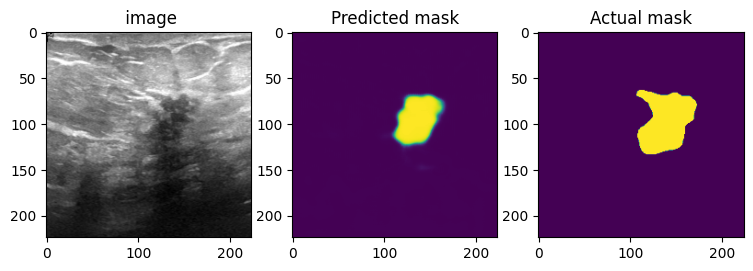

In [ ]:
Plotter(actuals[7], sixteenPrediction[7][:,:,0], masks[7])

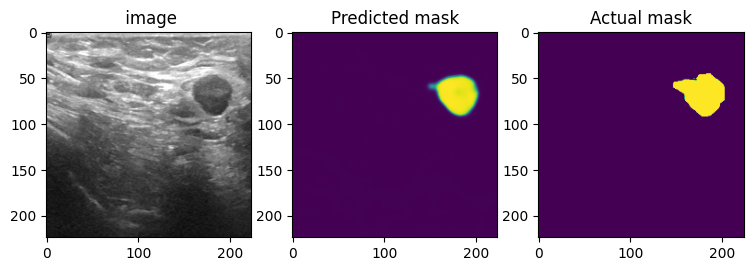

In [ ]:
Plotter(actuals[9], sixteenPrediction[9][:,:,0], masks[9])

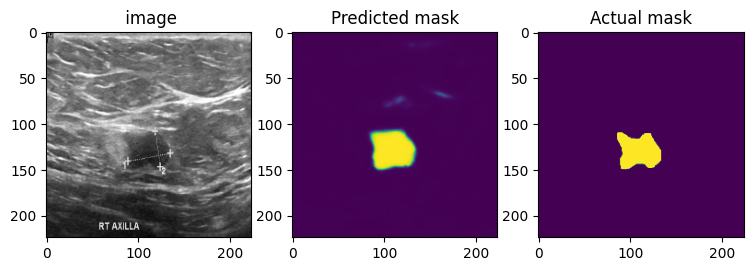

In [ ]:
Plotter(actuals[10], sixteenPrediction[10][:,:,0], masks[10])

In [ ]:
#Saving Model
rkoshaheds_model.save('/content/drive/MyDrive/dataset/malignant_predicted_mask.h5')

##Using the trained model to segment images from DATASET_2:

Loading the trained model:

In [ ]:
from tensorflow.keras.models import load_model

# Load the trained U-Net models
benign_model = load_model('/content/drive/MyDrive/dataset/benign_predicted_mask.h5', compile=False)
malignant_model = load_model('/content/drive/MyDrive/dataset/malignant_predicted_mask.h5', compile=False)

Prepare Dataset 2 for Segmentation

In [ ]:
import cv2
import numpy as np
import os
from tensorflow.keras.models import load_model

# Path to Dataset 2 images
dataset2_path = '/content/augmented_dataset_2'

# Output paths for segmented masks
benign_masks_path = '/content/benign_segmented_image'
malignant_masks_path = '/content/malignant_segmented_image'

# Create output folders if they do not exist
os.makedirs(benign_masks_path, exist_ok=True)
os.makedirs(malignant_masks_path, exist_ok=True)

IMAGE_SIZE = (224, 224)

# Load the trained U-Net models
benign_model = load_model('/content/drive/MyDrive/dataset/benign_predicted_mask.h5', compile=False)
malignant_model = load_model('/content/drive/MyDrive/dataset/malignant_predicted_mask.h5', compile=False)

**Segmenting mask:**
Here I used, bitwise_and operation to segment the mask from dataset 2 using the saved model.

In [ ]:
# Traverse through the nested directories
for class_dir in os.listdir(dataset2_path):
    class_path = os.path.join(dataset2_path, class_dir)

    # Process only 'benign' and 'malignant' folders
    if class_dir in ['benign', 'malignant'] and os.path.isdir(class_path):
        for filename in os.listdir(class_path):
            if filename.endswith(('.png', '.jpg', '.jpeg')):
                try:
                    # Load image
                    image_path = os.path.join(class_path, filename)
                    image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)

                    if image is None:
                        print(f"Warning: Unable to load image {filename}. Skipping.")
                        continue

                    # Convert grayscale to RGB
                    image_rgb = cv2.cvtColor(image, cv2.COLOR_GRAY2RGB)

                    # Preprocess image
                    resized_image = cv2.resize(image_rgb, IMAGE_SIZE)
                    input_image = resized_image / 255.0  # Normalize to [0, 1]
                    input_image = np.expand_dims(input_image, axis=0)  # Add batch dimension

                    # Predict masks using both models
                    benign_mask = benign_model.predict(input_image)[0, :, :, 0]
                    malignant_mask = malignant_model.predict(input_image)[0, :, :, 0]

                    # Apply masks to original image using bitwise AND
                    benign_segmented = cv2.bitwise_and(resized_image, resized_image, mask=(benign_mask > 0.5).astype(np.uint8) * 255)
                    malignant_segmented = cv2.bitwise_and(resized_image, resized_image, mask=(malignant_mask > 0.5).astype(np.uint8) * 255)

                    # Save the segmented images (result of bitwise AND)
                    if class_dir == 'benign':
                        cv2.imwrite(os.path.join(benign_masks_path, f"benign_segmented_{filename}"), benign_segmented)
                    elif class_dir == 'malignant':
                        cv2.imwrite(os.path.join(malignant_masks_path, f"malignant_segmented_{filename}"), malignant_segmented)

                except Exception as e:
                    print(f"Error processing {filename}: {e}")

print("The masks have been segmented and saved in separate folders.")

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 802ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 801ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 172ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 166ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 180ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 164ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 165ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 170ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 165ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 163ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 183ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 163ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 243ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 292ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 294ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 297ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 278ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 288ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 305ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 296ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 273ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 297ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 250ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 171ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 181ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 

#**Part 02: Processing**

##Merge the segmented datasets

Merging and Saving Segmented Images

In [ ]:
import shutil
import os

output_folder = '/content/merged_images'  #  output folder path
os.makedirs(output_folder, exist_ok=True)  # Create if it doesn't exist

# Copy segmented images
benign_segmented_path = '/content/benign_segmented_image'  # Path to benign segmented images
malignant_segmented_path = '/content/malignant_segmented_image'  # Path to malignant segmented images
normal_segmented_path = '/content/augmented_dataset_2/normal'  # Path to normal  images

for path, class_name in [(benign_segmented_path, 'benign'),
                         (malignant_segmented_path, 'malignant'),
                         (normal_segmented_path, 'normal')]:
    # Create class subdirectory within output_folder
    os.makedirs(os.path.join(output_folder, class_name), exist_ok=True)

    for filename in os.listdir(path):
        if filename.endswith(('.png', '.jpg', '.jpeg')):
            source_path = os.path.join(path, filename)
            destination_path = os.path.join(output_folder, class_name, filename)
            shutil.copy(source_path, destination_path)

In [ ]:
import shutil
shutil.make_archive('/content/drive/MyDrive/dataset/merged_images', 'zip', output_folder)

'/content/drive/MyDrive/dataset/merged_images.zip'

Folder 'normal' contains 410 files.
Folder 'benign' contains 410 files.
Folder 'malignant' contains 410 files.


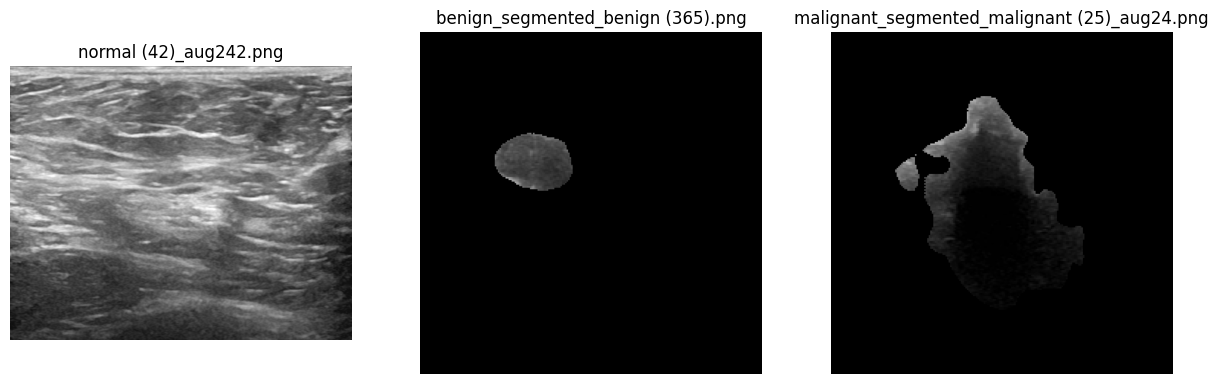

In [ ]:
import matplotlib.pyplot as plt
import cv2
import os

# Load and display a sample ultrasound image and its mask from Dataset 1
base_image_path = '/content/merged_images'
subfolders = ['normal', 'benign', 'malignant']

fig, axes = plt.subplots(1, 3, figsize=(15, 5))  # 1 row, 5 columns

# Iterate through subfolders and plot one image from each
for i, subfolder in enumerate(subfolders):
    folder_path = os.path.join(base_image_path, subfolder)
    file_count = len([f for f in os.listdir(folder_path) if os.path.isfile(os.path.join(folder_path, f))])
    print(f"Folder '{subfolder}' contains {file_count} files.")

    input_path = os.path.join(base_image_path, subfolder)

    # Get a list of image files and sort them
    image_files = [f.path for f in os.scandir(input_path) if f.is_file()]
    image_files.sort()

    # Get the first image file (after sorting)
    image_file = image_files[259]
    image_name = os.path.basename(image_file)  # Get the image file name

    # Read and display the image
    image = cv2.imread(image_file)
    image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)  # Convert to RGB for matplotlib
    axes[i].imshow(image_rgb)
    axes[i].set_title(subfolder)
    axes[i].set_title(f"{image_name}")  # Include image name in title
    axes[i].axis('off')  # Turn off axis ticks and labels

plt.show()

#**Part 03: Developing the Hybrid Classification Model:**

##Dataset Split

0.7: 70% of the data will be used for training.

0.2: 20% of the data will be used for validation.

0.1: 10% of the data will be used for testing.

In [ ]:
!pip install split-folders

Train the classification model using segmented Regions of Interest (ROI) from the **merged dataset**.



In [ ]:
import splitfolders
import os

input = '/content/merged_dataset'
output = '/content/split_dataset'

os.makedirs(output, exist_ok=True)

splitfolders.ratio(input, output, seed=42, ratio=(0.7, 0.2, 0.1)) # train = 70%, val = 20%, test = 10%

Copying files: 1230 files [00:00, 2357.06 files/s]
